# Question 2
What factors go into making an asteroid potentially hazardous or not?

First we sort the data by `miss_distance_km` to find the NEOs that are closest to Earth. First up is a histogram showing `estimated_diameter_max_km`, which is the upper bound for the diamater of the object. We can see that most of them are less than 0.2 km (200 m) in diameter.

Number of asteroids marked as potentially hazardous:
0
First 10 rows of near misses:
   id neo_reference_id         name                                                     nasa_jpl_url  absolute_magnitude_h  estimated_diameter_min_km  estimated_diameter_max_km  is_potentially_hazardous_asteroid close_approach_date close_approach_date_full  relative_velocity_kph  miss_distance_km orbiting_body  is_sentry_object          ingested_at
0  49         54347996   (2023 DZ2)  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996                24.280                   0.037030                   0.082802                                  0          2026-04-04        2026-Apr-04 02:04           26061.586230      1.012422e+06         Earth                 0  2026-04-03 23:48:04
1  31          3560131   (2011 FT9)   https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3560131                26.200                   0.015295                   0.034201                                  0  

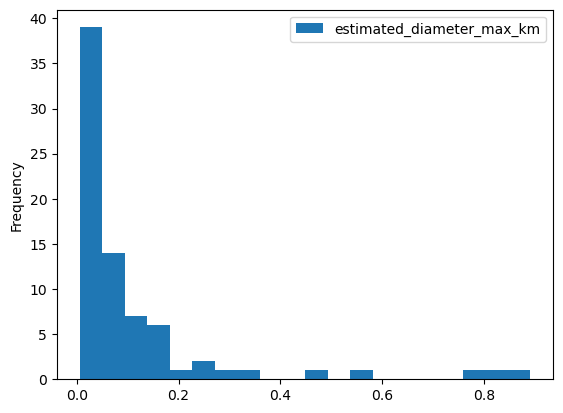

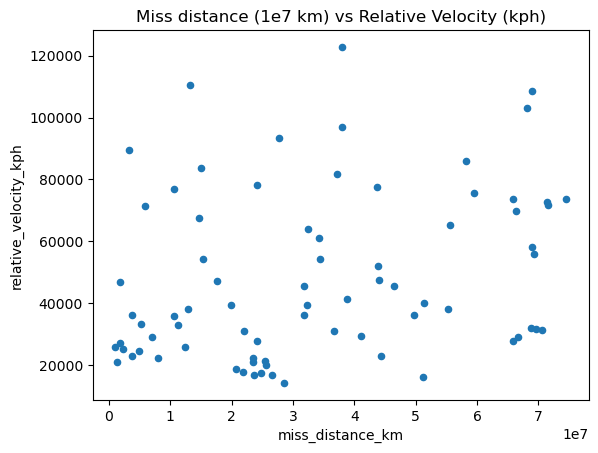

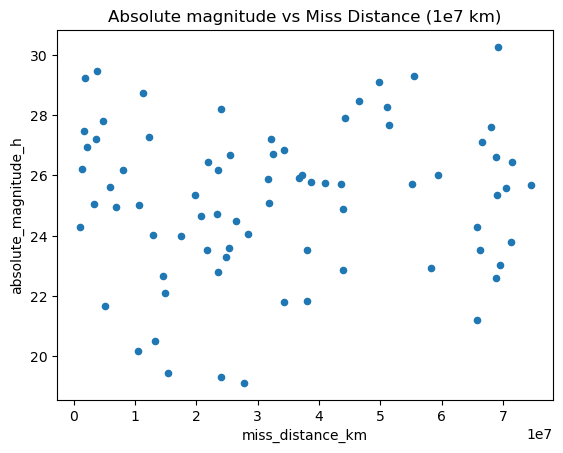

In [2]:
%run ./main.ipynb

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# print(df_all.size)


# print("First 10 rows of all data:")
# print(df_all.head(10).to_string())

# count of potentially hazardous asteroids (usually 0)
print("Number of asteroids marked as potentially hazardous:")
df_hazardous = df_clean.query("is_potentially_hazardous_asteroid != 0")
print(df_hazardous.size)

# Near miss data table
df_near_miss = df_clean.sort_values(by="miss_distance_km")
print("First 10 rows of near misses:")
print(df_near_miss.head(10).to_string())


# Histogram
print("Histogram of estimated diameter max in km:")
df_near_miss.plot.hist(column="estimated_diameter_max_km", bins=20)

# Scatter plot
print("Scatter plot of relative velocity vs. miss distance:")
df_near_miss.plot.scatter(title="Miss distance (1e7 km) vs Relative Velocity (kph)", y="relative_velocity_kph", x="miss_distance_km")

# Scatter plot 2
print("Scatter plot of brightness vs. miss distance:")
df_near_miss.plot.scatter(title="Absolute magnitude vs Miss Distance (1e7 km)", x="miss_distance_km", y="absolute_magnitude_h")

# turning the values into numpy arrays for linear regression
diam = np.array(df_clean["estimated_diameter_max_km"])
rv = np.array(df_clean["relative_velocity_kph"])

# linear regression with scipy
# slope, intercept, r_value, p_value, std_err = stats.linregress(diam, rv)
# plt.scatter(diam, rv)

# values for line of best fit (not working correctly)
# x_line = np.sort(diam)
# y_line = intercept + slope * x_line
# plt.plot(x_line, y_line, 'r', label='fitted line')



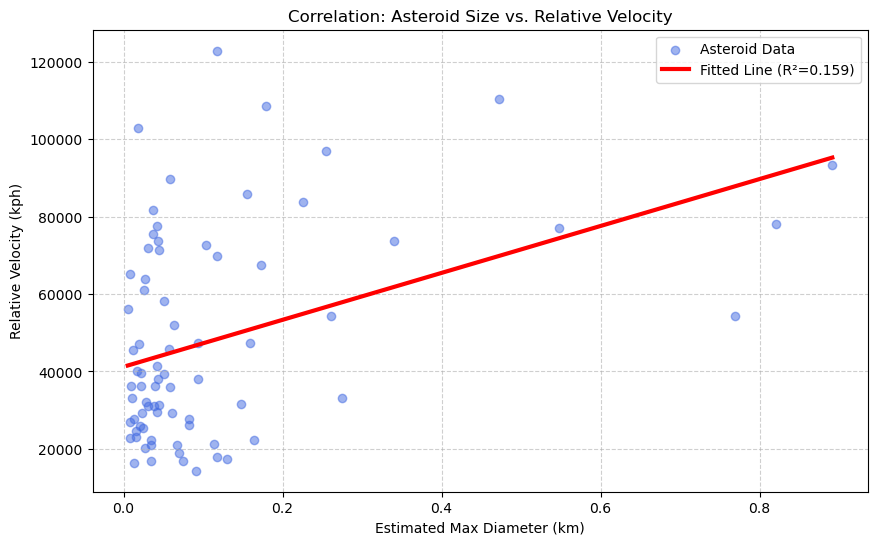

R-squared: 0.1592
P-value: 0.0004
Result: There is a statistically significant relationship.


In [4]:
# --- Linear Regression Section ---
# 1. Clean the data for regression (linregress fails if there are NaNs)
# We create a 'mask' to find rows where both diam and rv have valid numbers
mask = ~np.isnan(diam) & ~np.isnan(rv)
clean_diam = diam[mask]
clean_rv = rv[mask]

# 2. Run the regression
slope, intercept, r_value, p_value, std_err = stats.linregress(clean_diam, clean_rv)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(clean_diam, clean_rv, alpha=0.5, label='Asteroid Data', color='royalblue')

# 4. Calculate the line of best fit
# We only need two points to draw a straight line: the min and max of our x-axis
x_line = np.array([clean_diam.min(), clean_diam.max()])
y_line = intercept + slope * x_line

plt.plot(x_line, y_line, color='red', linewidth=3, label=f'Fitted Line (R²={r_value**2:.3f})')

# 5. Formatting
plt.title("Correlation: Asteroid Size vs. Relative Velocity")
plt.xlabel("Estimated Max Diameter (km)")
plt.ylabel("Relative Velocity (kph)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Statistical Output
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: There is a statistically significant relationship.")
else:
    print("Result: No strong statistical relationship between size and velocity.")

## Findings
 